In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
import pandas as pd

train = pd.read_csv("C:/Users/kmpsh/Downloads/Msc/Projects/Retail_Forecasting_ML/data/raw/train.csv")
store = pd.read_csv("C:/Users/kmpsh/Downloads/Msc/Projects/Retail_Forecasting_ML/data/raw/store.csv")

print(train.shape)
print(store.shape)

(1017209, 9)
(1115, 10)


C:\Users\kmpsh\AppData\Local\Temp\ipykernel_56504\2983579439.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/kmpsh/Downloads/Msc/Projects/Retail_Forecasting_ML/data/raw/train.csv")


In [8]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [9]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [11]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


# Data Cleaning

In [13]:
train["Date"] = pd.to_datetime(train["Date"])

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


## merging

In [16]:
df = train.merge(store, on ="Store", how = "left")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [17]:
df.shape

(1017209, 18)

In [18]:
df[df["Open"]==0].shape

(172817, 18)

In [19]:
type(df)

pandas.core.frame.DataFrame

## remove closed stores

In [21]:
df = df[df["Open"] == 1]

In [22]:
df.shape

(844392, 18)

In [23]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [24]:
type(df)
df.shape

(844392, 18)

# Time Based Feature Engineering

In [26]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekofyear"] = df["Date"].dt.isocalendar().week
df["dayofweek"] = df["Date"].dt.dayofweek

In [27]:
df[["Date", "year" ,"month", "day", "weekofyear", "dayofweek"]].head()

,Date,year,month,day,weekofyear,dayofweek
0,2015-07-31,2015,7,31,31,4
1,2015-07-31,2015,7,31,31,4
2,2015-07-31,2015,7,31,31,4
3,2015-07-31,2015,7,31,31,4
4,2015-07-31,2015,7,31,31,4


## Check Seasonality

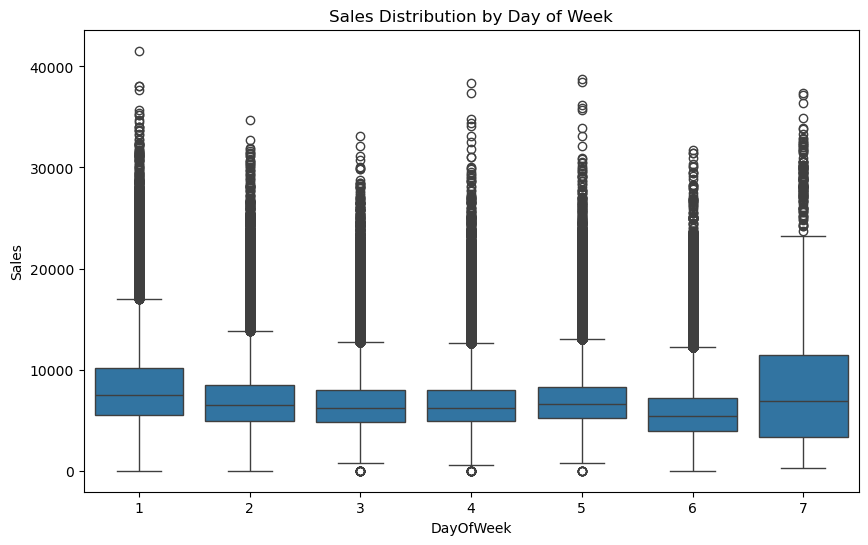

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(x="DayOfWeek", y="Sales", data=df)
plt.title("Sales Distribution by Day of Week")
plt.show()

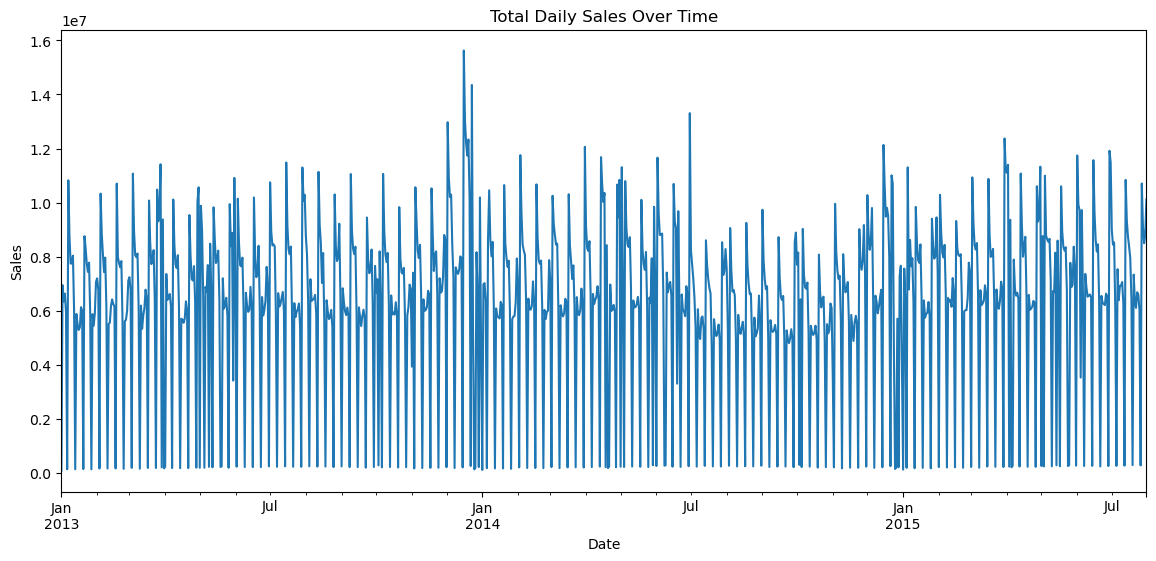

In [30]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(14,6))
daily_sales.plot()
plt.title("Total Daily Sales Over Time")
plt.ylabel("Sales")
plt.show()

In [31]:
df[["StoreType","Assortment"]].value_counts().head()

StoreType  Assortment
a          a             286053
           c             171024
d          c             164888
           a              93886
c          a              58561
Name: count, dtype: int64

In [58]:
df= df.sort_values(["Store","Date"])

# Feature Engineering

## Lag features

In [82]:
df["lag_1"]= df.groupby("Store")["Sales"].shift(1)
df["lag_7"]=df.groupby("Store")["Sales"].shift(7)
df["lag_14"] = df.groupby("Store")["Sales"].shift(14)
df["lag_28"] = df.groupby("Store")["Sales"].shift(28)

## Rolling average

In [67]:
df["rolling_mean_7"] = df.groupby("Store")["Sales"].shift(1).rolling(7).mean()
df["rolling_mean_30"] = df.groupby("Store")["Sales"].shift(1).rolling(30).mean()

## Remove missing values~

In [70]:
df = df.dropna()

In [72]:
df.shape

(256862, 29)

In [84]:
df[["Sales","lag_1","lag_7","rolling_mean_7"]].head(10)

,Sales,lag_1,lag_7,rolling_mean_7
975956,6438,NaN,NaN,4642.428571
974841,5575,6438.0,NaN,5067.714286
973726,4203,5575.0,NaN,5229.000000
972611,3031,4203.0,NaN,5209.428571
970381,4303,3031.0,NaN,4993.142857
969266,3968,4303.0,NaN,5185.571429
968151,5001,3968.0,NaN,4826.714286
967036,4439,5001.0,6438.0,4645.571429
965921,3812,4439.0,5575.0,4360.000000
964806,2401,3812.0,4203.0,4108.142857


In [86]:
df = df.dropna()

In [88]:
df.shape

(246642, 30)

Raw dataset
      ↓
Data cleaning
      ↓
Merge store metadata
      ↓
Remove closed stores
      ↓
EDA
      ↓
Time features
      ↓
Lag features
      ↓
Rolling features
      ↓
Final ML dataset

## Prepare Features and Target

In [94]:
X = df.drop(columns=["Sales", "Date"])
y = df["Sales"]

## Time Based Train/Test Split

In [181]:
train = df[df["Date"] < "2015-01-01"]
test = df[df["Date"] >= "2015-01-01"]

x_train = train.drop(columns=["Sales", "Date"])
y_train = train["Sales"]

x_test = test.drop(columns=["Sales", "Date"])
y_test = test["Sales"]

In [183]:
x_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [185]:
x_train.shape

(182859, 28)

In [187]:
x_test.shape

(63783, 28)

In [189]:
x_train.dtypes

Store                          int64
DayOfWeek                      int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                   int32
SchoolHoliday                  int64
StoreType                      int32
Assortment                     int32
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                  int32
year                           int32
month                          int32
day                            int32
weekofyear                    UInt32
dayofweek                      int32
lag_1                        float64
lab_7                        float64
lag_14                       float64
lag_28                       float64
rolling_mean_7               float64
rolling_mean_30              float64
l

# Train Baseline Model

In [192]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)

## Encoding Strings

In [118]:
df.select_dtypes(include="object").columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

In [132]:
x_train.select_dtypes(include='object').columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

### lable Encoding

In [122]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["StateHoliday", "StoreType", "Assortment", "PromoInterval"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

In [177]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["StateHoliday", "StoreType", "Assortment", "PromoInterval"]

for col in categorical_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(X_train[col].astype(str))
    x_test[col] = le.transform(X_test[col].astype(str))

In [179]:
x_train.select_dtypes(include='object').columns

Index([], dtype='object')

## Predict the model

In [195]:
predictions = model.predict(x_test)

## Evaluate the Model

In [198]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 495.62135671672684
RMSE: 706.0482857402351


## Feature Importance

In [201]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
2,Customers,0.715338
21,lag_1,0.098428
26,rolling_mean_30,0.030984
4,Promo,0.029372
9,CompetitionDistance,0.024008
7,StoreType,0.021135
1,DayOfWeek,0.017872
20,dayofweek,0.016026
13,Promo2SinceWeek,0.006234
11,CompetitionOpenSinceYear,0.005711


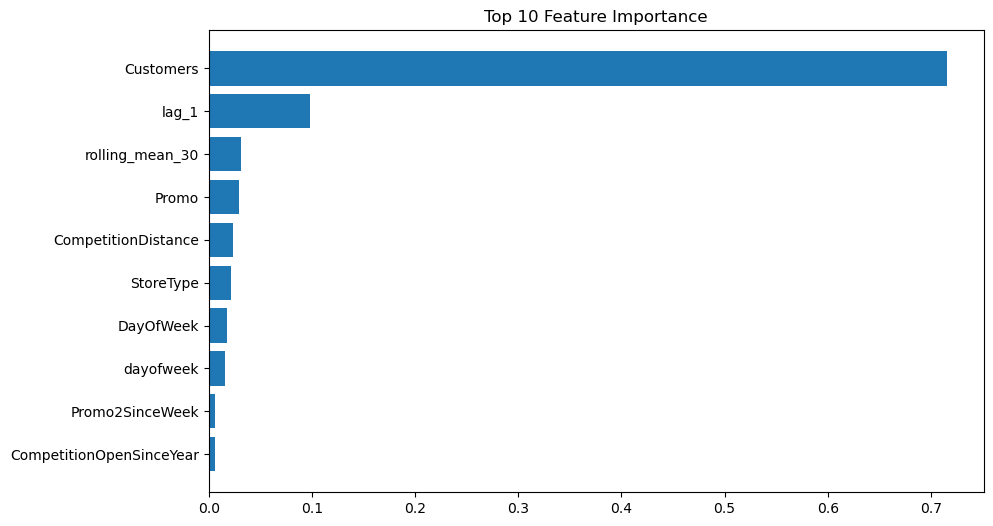

In [203]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

# XG Boost Model

In [206]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 11.2 MB/s eta 0:00:10
   - -------------------------------------- 2.9/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 4.5/101.7 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.6/101.7 MB 9.4 MB/s eta 0:00:11
   --- ------------------------------------ 8.1/101.7 MB 9.1 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/101.7 MB 9.9 MB/s eta 0:00:10
   ----- ---------------------------------- 13.9/101.7 MB 10.6 MB/s eta 0:00:09
   ------ --------------------------------- 16.5/101.7 MB 10.7 MB/s eta 0:00:08
   ------- -------------------------------- 19.9/101.7 MB 11.2 MB/s eta 0:00:08
   -------- ------------------------------- 22.0/101.7 MB 11.3 MB/s eta 0:00:08
   --------- ------------------------------ 24.4/101.7 MB 11.3 MB/s eta 0:00:07
   ---------- ----------------------------- 27.3/101.7 MB 1

In [208]:
from xgboost import XGBRegressor

## Create XGBoost Model

In [210]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

## Training XGBoost Model

In [212]:
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

### Model Predictions

In [214]:
xgb_predictions = xgb_model.predict(x_test)

## Model Evaluation

In [222]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost MAE:", xgb_mae)
 jprint("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 363.13116254699315
XGBoost RMSE: 523.4223399961446


## Compare Models

In [225]:
print("Random Forest MAE:", mae)
print("XGBoost MAE:", xgb_mae)

print("Random Forest RMSE:", rmse)
print("XGBoost RMSE:", xgb_rmse)

Random Forest MAE: 495.62135671672684
XGBoost MAE: 363.13116254699315
Random Forest RMSE: 706.0482857402351
XGBoost RMSE: 523.4223399961446


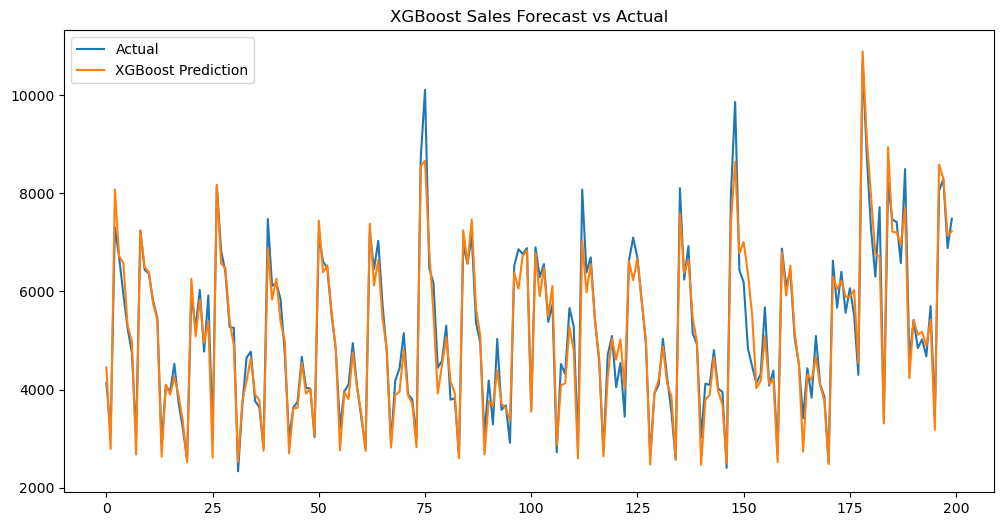

In [227]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(xgb_predictions[:200], label="XGBoost Prediction")

plt.legend()
plt.title("XGBoost Sales Forecast vs Actual")
plt.show()

### Feature Importance 

In [232]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
2,Customers,0.348860
4,Promo,0.140507
7,StoreType,0.085518
21,lag_1,0.075887
20,dayofweek,0.074282
25,rolling_mean_7,0.057787
26,rolling_mean_30,0.031640
1,DayOfWeek,0.027801
9,CompetitionDistance,0.023945
14,Promo2SinceYear,0.018457


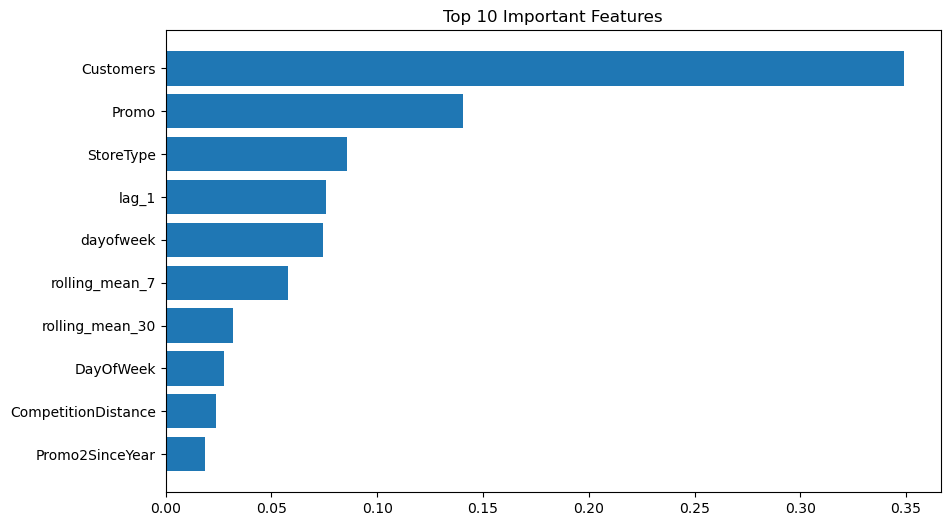

In [234]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
 plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

# Save the Model

In [237]:
 import joblib

joblib.dump(xgb_model, "xgb_sales_forecast_model.pkl")

['xgb_sales_forecast_model.pkl']

In [239]:
df.to_csv("forecast_dataset.csv", index=False)